# 09. Exportación de resultados para plataforma analítica

Este notebook corresponde al Nivel 6 de la metodología. Su objetivo es preparar los artefactos finales que serán consumidos por una futura plataforma analítica AML.

En los niveles previos se observó que XGBoost baseline obtuvo el mejor desempeño general según PR-AUC, mientras que Random Forest mostró un comportamiento más conservador con alta precisión. Las GNN y los subgrafos aportaron valor exploratorio y descriptivo, pero no superaron de forma consistente al baseline clásico.

Por ello, en este nivel se usará XGBoost baseline como modelo principal para generar scores de riesgo, alertas y archivos exportables.

In [1]:
# Imports y rutas
import sys
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from aml_gnn.utils.paths import INTERIM_DIR, PROCESSED_DIR, REPORTS_DIR, MODELS_DIR, EXPERIMENTS_DIR

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INTERIM_DIR:", INTERIM_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("REPORTS_DIR:", REPORTS_DIR)
print("MODELS_DIR:", MODELS_DIR)

PROJECT_ROOT: /home/lucho/aml-gnn-tesis
INTERIM_DIR: /home/lucho/aml-gnn-tesis/data/interim/elliptic
PROCESSED_DIR: /home/lucho/aml-gnn-tesis/data/processed/elliptic
REPORTS_DIR: /home/lucho/aml-gnn-tesis/reports
MODELS_DIR: /home/lucho/aml-gnn-tesis/models


In [2]:
# Creando carpetas de salida
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

tables_dir = REPORTS_DIR / "tables"
figures_dir = REPORTS_DIR / "figures"
metrics_dir = REPORTS_DIR / "metrics"
experiment_dir = EXPERIMENTS_DIR / "05_platform_export"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)
experiment_dir.mkdir(parents=True, exist_ok=True)

print("Directorios listos.")

Directorios listos.


## Consolidar comparación final de modelos

In [3]:
# Función auxiliar para compactar métricas
def compact_metrics(model_name, metrics_dict, split="test", family=""):
    return {
        "model": model_name,
        "family": family,
        "split": split,
        "accuracy": metrics_dict.get("accuracy"),
        "precision": metrics_dict.get("precision"),
        "recall": metrics_dict.get("recall"),
        "f1": metrics_dict.get("f1"),
        "pr_auc": metrics_dict.get("pr_auc"),
        "roc_auc": metrics_dict.get("roc_auc"),
        "recall_at_50": metrics_dict.get("recall_at_50"),
        "recall_at_100": metrics_dict.get("recall_at_100"),
        "recall_at_500": metrics_dict.get("recall_at_500"),
        "recall_at_1000": metrics_dict.get("recall_at_1000"),
    }

In [4]:
# Cargando métricas previas
baseline_metrics_path = metrics_dir / "baseline_metrics.json"
gnn_metrics_path = metrics_dir / "gnn_node_metrics.json"
gnn_full_metrics_path = metrics_dir / "gnn_node_metrics_full_context.json"
level_5_metrics_path = metrics_dir / "level_5_subgraph_baseline_metrics.json"

available_files = {
    "baseline_metrics": baseline_metrics_path.exists(),
    "gnn_metrics": gnn_metrics_path.exists(),
    "gnn_full_metrics": gnn_full_metrics_path.exists(),
    "level_5_metrics": level_5_metrics_path.exists(),
}

available_files

{'baseline_metrics': True,
 'gnn_metrics': True,
 'gnn_full_metrics': True,
 'level_5_metrics': True}

In [5]:
# Construyendo tabla final de comparación
comparison_rows = []

if baseline_metrics_path.exists():
    with open(baseline_metrics_path, "r", encoding="utf-8") as file:
        baseline_metrics = json.load(file)

    comparison_rows.extend([
        compact_metrics(
            "Logistic Regression baseline",
            baseline_metrics["logistic_regression"]["test"],
            family="baseline_classic"
        ),
        compact_metrics(
            "Random Forest baseline",
            baseline_metrics["random_forest"]["test"],
            family="baseline_classic"
        ),
        compact_metrics(
            "XGBoost baseline",
            baseline_metrics["xgboost"]["test"],
            family="baseline_classic"
        ),
    ])

if gnn_metrics_path.exists():
    with open(gnn_metrics_path, "r", encoding="utf-8") as file:
        gnn_metrics = json.load(file)

    comparison_rows.extend([
        compact_metrics(
            "GCN 3A supervised-only",
            gnn_metrics["gcn"]["test"],
            family="gnn_node"
        ),
        compact_metrics(
            "GraphSAGE 3A supervised-only",
            gnn_metrics["graphsage"]["test"],
            family="gnn_node"
        ),
    ])

if gnn_full_metrics_path.exists():
    with open(gnn_full_metrics_path, "r", encoding="utf-8") as file:
        gnn_full_metrics = json.load(file)

    comparison_rows.extend([
        compact_metrics(
            "GCN 3B full-context",
            gnn_full_metrics["gcn_full_context"]["test"],
            family="gnn_node_full_context"
        ),
        compact_metrics(
            "GraphSAGE 3B full-context",
            gnn_full_metrics["graphsage_full_context"]["test"],
            family="gnn_node_full_context"
        ),
    ])

if level_5_metrics_path.exists():
    with open(level_5_metrics_path, "r", encoding="utf-8") as file:
        level_5_metrics = json.load(file)

    comparison_rows.extend([
        compact_metrics(
            "Random Forest subgraph-only",
            level_5_metrics["random_forest_subgraph_only"]["test"],
            family="subgraph_baseline"
        ),
        compact_metrics(
            "XGBoost subgraph-only",
            level_5_metrics["xgboost_subgraph_only"]["test"],
            family="subgraph_baseline"
        ),
        compact_metrics(
            "Random Forest original+subgraph",
            level_5_metrics["random_forest_original_plus_subgraph"]["test"],
            family="subgraph_enriched"
        ),
        compact_metrics(
            "XGBoost original+subgraph",
            level_5_metrics["xgboost_original_plus_subgraph"]["test"],
            family="subgraph_enriched"
        ),
    ])

final_model_comparison_df = pd.DataFrame(comparison_rows)

final_model_comparison_df = final_model_comparison_df.sort_values(
    by="pr_auc",
    ascending=False
).reset_index(drop=True)

final_model_comparison_df

,model,family,split,accuracy,precision,recall,f1,pr_auc,roc_auc,recall_at_50,recall_at_100,recall_at_500,recall_at_1000
0,XGBoost baseline,baseline_classic,test,0.956905,0.536585,0.485294,0.509653,0.561439,0.873378,0.122549,0.245098,0.504902,0.558824
1,XGBoost original+subgraph,subgraph_enriched,test,0.957018,0.538043,0.485294,0.510309,0.550255,0.860891,0.122549,0.237745,0.500000,0.553922
2,Random Forest original+subgraph,subgraph_enriched,test,0.974098,0.958974,0.458333,0.620232,0.548072,0.864373,0.122549,0.245098,0.485294,0.531863
3,Random Forest baseline,baseline_classic,test,0.974098,0.958974,0.458333,0.620232,0.547510,0.851448,0.122549,0.245098,0.490196,0.529412
4,GCN 3A supervised-only,gnn_node,test,0.630359,0.090727,0.776961,0.162481,0.253016,0.799663,0.051471,0.100490,0.397059,0.473039
5,GraphSAGE 3B full-context,gnn_node_full_context,test,0.667232,0.098542,0.762255,0.174523,0.252182,0.805429,0.073529,0.139706,0.350490,0.438725
6,Logistic Regression baseline,baseline_classic,test,0.727746,0.123540,0.803922,0.214169,0.199037,0.855272,0.007353,0.051471,0.375000,0.517157
7,GraphSAGE 3A supervised-only,gnn_node,test,0.617803,0.089754,0.796569,0.161330,0.195462,0.790640,0.041667,0.063725,0.360294,0.473039
8,GCN 3B full-context,gnn_node_full_context,test,0.721072,0.114895,0.752451,0.199351,0.153516,0.797965,0.012255,0.041667,0.237745,0.426471
9,XGBoost subgraph-only,subgraph_baseline,test,0.783961,0.100956,0.465686,0.165939,0.113318,0.730058,0.022059,0.061275,0.166667,0.269608


In [6]:
# Seleccionar modelo principal
primary_model_row = final_model_comparison_df.iloc[0].to_dict()

primary_model_row

{'model': 'XGBoost baseline',
 'family': 'baseline_classic',
 'split': 'test',
 'accuracy': 0.9569053274516457,
 'precision': 0.5365853658536586,
 'recall': 0.4852941176470588,
 'f1': 0.5096525096525096,
 'pr_auc': 0.5614390083383461,
 'roc_auc': 0.8733779293764227,
 'recall_at_50': 0.12254901960784313,
 'recall_at_100': 0.24509803921568626,
 'recall_at_500': 0.5049019607843137,
 'recall_at_1000': 0.5588235294117647}

In [7]:
# Guardando comparación final
final_model_comparison_path = tables_dir / "final_model_comparison.csv"

final_model_comparison_df.to_csv(final_model_comparison_path, index=False)

print("Guardado:", final_model_comparison_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/tables/final_model_comparison.csv


## Generar predicciones y scores de riesgo

In [8]:
# Cargando nodos y modelo principal
nodes_path = INTERIM_DIR / "nodes_with_graph_features.parquet"
xgb_model_path = MODELS_DIR / "baseline_xgboost.pkl"

nodes_df = pd.read_parquet(nodes_path)
xgb_model = joblib.load(xgb_model_path)

print("Nodes:", nodes_df.shape)
print("Modelo cargado:", xgb_model_path)

nodes_df[["txId", "timestep", "label", "in_degree", "out_degree", "total_degree"]].head()

Nodes: (203769, 171)
Modelo cargado: /home/lucho/aml-gnn-tesis/models/baseline_xgboost.pkl


,txId,timestep,label,in_degree,out_degree,total_degree
0,230425980,1,unknown,1,1,2
1,5530458,1,unknown,1,1,2
2,232022460,1,unknown,1,2,3
3,232438397,1,licit,160,1,161
4,230460314,1,unknown,2,8,10


In [9]:
# Definiendo features usadas por XGBoost baseline
original_feature_cols = [
    col for col in nodes_df.columns
    if col.startswith("f_")
]

graph_feature_cols = [
    "in_degree",
    "out_degree",
    "total_degree"
]

platform_feature_cols = original_feature_cols + graph_feature_cols

print("Features originales:", len(original_feature_cols))
print("Features estructurales simples:", len(graph_feature_cols))
print("Features totales:", len(platform_feature_cols))

missing_features = [
    col for col in platform_feature_cols
    if col not in nodes_df.columns
]

missing_features

Features originales: 165
Features estructurales simples: 3
Features totales: 168


[]

In [10]:
# Generando scores para todos los nodos
X_platform = nodes_df[platform_feature_cols]

score_illicit = xgb_model.predict_proba(X_platform)[:, 1]

platform_predictions_df = nodes_df[
    [
        "txId",
        "timestep",
        "label",
        "in_degree",
        "out_degree",
        "total_degree"
    ]
].copy()

platform_predictions_df["score_illicit"] = score_illicit
platform_predictions_df["predicted_class"] = np.where(
    platform_predictions_df["score_illicit"] >= 0.5,
    "illicit",
    "licit"
)

platform_predictions_df.head()

,txId,timestep,label,in_degree,out_degree,total_degree,score_illicit,predicted_class
0,230425980,1,unknown,1,1,2,0.004249,licit
1,5530458,1,unknown,1,1,2,0.024910,licit
2,232022460,1,unknown,1,2,3,0.035242,licit
3,232438397,1,licit,160,1,161,0.000046,licit
4,230460314,1,unknown,2,8,10,0.000018,licit


In [11]:
# Creando niveles de riesgo
def probability_risk_level(score):
    if score >= 0.80:
        return "high"
    if score >= 0.50:
        return "medium"
    return "low"


platform_predictions_df["risk_level_probability"] = platform_predictions_df[
    "score_illicit"
].apply(probability_risk_level)

# Percentil de riesgo para priorización operativa
platform_predictions_df["risk_percentile"] = (
    platform_predictions_df["score_illicit"]
    .rank(pct=True)
    * 100
)

def percentile_priority_level(percentile):
    if percentile >= 99:
        return "critical"
    if percentile >= 95:
        return "high"
    if percentile >= 80:
        return "medium"
    return "low"


platform_predictions_df["priority_level"] = platform_predictions_df[
    "risk_percentile"
].apply(percentile_priority_level)

platform_predictions_df = platform_predictions_df.sort_values(
    by="score_illicit",
    ascending=False
).reset_index(drop=True)

platform_predictions_df["risk_rank"] = np.arange(1, len(platform_predictions_df) + 1)

platform_predictions_df.head(20)

,txId,timestep,label,in_degree,out_degree,total_degree,score_illicit,predicted_class,risk_level_probability,risk_percentile,priority_level,risk_rank
0,283172687,25,illicit,0,1,1,0.999955,illicit,high,100.000000,critical,1
1,209522745,20,illicit,1,1,2,0.999954,illicit,high,99.999509,critical,2
2,372726129,22,illicit,1,1,2,0.999952,illicit,high,99.999018,critical,3
3,99153076,21,unknown,1,1,2,0.999952,illicit,high,99.998528,critical,4
4,372726603,22,illicit,1,1,2,0.999949,illicit,high,99.998037,critical,5
5,244629901,15,illicit,0,1,1,0.999947,illicit,high,99.997546,critical,6
6,85000165,26,illicit,1,0,1,0.999947,illicit,high,99.997055,critical,7
7,244629220,15,illicit,0,1,1,0.999947,illicit,high,99.996565,critical,8
8,85258388,26,illicit,1,0,1,0.999943,illicit,high,99.996074,critical,9
9,339095621,13,illicit,0,1,1,0.999943,illicit,high,99.995583,critical,10


In [12]:
# Resumen de niveles de riesgo
risk_level_summary = (
    platform_predictions_df
    .groupby(["priority_level", "label"])
    .size()
    .reset_index(name="count")
)

risk_level_summary

,priority_level,label,count
0,critical,illicit,1491
1,critical,unknown,547
2,high,illicit,2621
3,high,licit,15
4,high,unknown,5515
5,low,illicit,256
6,low,licit,40816
7,low,unknown,121943
8,medium,illicit,177
9,medium,licit,1188


In [13]:
# Guardando predicciones de plataforma
platform_predictions_path = PROCESSED_DIR / "platform_predictions.parquet"

platform_predictions_df.to_parquet(platform_predictions_path, index=False)

print("Guardado:", platform_predictions_path)
print("Shape:", platform_predictions_df.shape)

Guardado: /home/lucho/aml-gnn-tesis/data/processed/elliptic/platform_predictions.parquet
Shape: (203769, 12)


## Generar alertas principales

In [14]:
# Creando top alertas
top_n_alerts = 1000

platform_alerts_top_df = platform_predictions_df.head(top_n_alerts).copy()

platform_alerts_top_df.head()

,txId,timestep,label,in_degree,out_degree,total_degree,score_illicit,predicted_class,risk_level_probability,risk_percentile,priority_level,risk_rank
0,283172687,25,illicit,0,1,1,0.999955,illicit,high,100.000000,critical,1
1,209522745,20,illicit,1,1,2,0.999954,illicit,high,99.999509,critical,2
2,372726129,22,illicit,1,1,2,0.999952,illicit,high,99.999018,critical,3
3,99153076,21,unknown,1,1,2,0.999952,illicit,high,99.998528,critical,4
4,372726603,22,illicit,1,1,2,0.999949,illicit,high,99.998037,critical,5


In [15]:
# Resumen de alertas top
alert_summary = (
    platform_alerts_top_df
    .groupby(["label", "priority_level"])
    .size()
    .reset_index(name="count")
)

alert_summary

,label,priority_level,count
0,illicit,critical,757
1,unknown,critical,243


In [16]:
# Guardando alertas top
platform_alerts_top_path = PROCESSED_DIR / "platform_alerts_top.parquet"

platform_alerts_top_df.to_parquet(platform_alerts_top_path, index=False)

print("Guardado:", platform_alerts_top_path)
print("Shape:", platform_alerts_top_df.shape)

Guardado: /home/lucho/aml-gnn-tesis/data/processed/elliptic/platform_alerts_top.parquet
Shape: (1000, 12)


## Generar subgraph alerts

In [17]:
# Cargando features de subgrafos
subgraph_features_path = PROCESSED_DIR / "subgraph_features_labeled.parquet"

if subgraph_features_path.exists():
    subgraph_features_df = pd.read_parquet(subgraph_features_path)
    print("Subgraph features:", subgraph_features_df.shape)
else:
    subgraph_features_df = None
    print("No existe:", subgraph_features_path)

Subgraph features: (93128, 21)


In [18]:
# Preparando features de subgrafos en formato ancho
if subgraph_features_df is not None:
    allowed_subgraph_cols = [
        "subgraph_num_nodes",
        "subgraph_num_edges",
        "subgraph_density",
        "center_in_degree",
        "center_out_degree",
        "center_total_degree",
        "avg_neighbor_total_degree",
        "max_neighbor_total_degree",
        "fan_in_out_ratio",
        "ratio_unknown_neighbors",
        "ratio_illicit_neighbors",
    ]

    subgraph_alert_df = subgraph_features_df[
        ["center_txId", "k"] + allowed_subgraph_cols
    ].copy()

    subgraph_alert_wide_df = subgraph_alert_df.pivot_table(
        index="center_txId",
        columns="k",
        values=allowed_subgraph_cols,
        aggfunc="first"
    )

    subgraph_alert_wide_df.columns = [
        f"{feature}_k{int(k)}"
        for feature, k in subgraph_alert_wide_df.columns
    ]

    subgraph_alert_wide_df = subgraph_alert_wide_df.reset_index()

    print("Subgraph alert wide:", subgraph_alert_wide_df.shape)
    subgraph_alert_wide_df.head()

Subgraph alert wide: (46564, 23)


In [19]:
# Uniendo alertas con subgrafos
if subgraph_features_df is not None:
    subgraph_alerts_df = platform_alerts_top_df.merge(
        subgraph_alert_wide_df,
        left_on="txId",
        right_on="center_txId",
        how="left"
    )

    subgraph_alerts_df = subgraph_alerts_df.drop(columns=["center_txId"])

    print("Subgraph alerts:", subgraph_alerts_df.shape)
    subgraph_alerts_df.head()

Subgraph alerts: (1000, 34)


In [20]:
# Guardando subgraph alerts
if subgraph_features_df is not None:
    subgraph_alerts_path = PROCESSED_DIR / "subgraph_alerts.parquet"

    subgraph_alerts_df.to_parquet(subgraph_alerts_path, index=False)

    print("Guardado:", subgraph_alerts_path)
else:
    subgraph_alerts_path = None

Guardado: /home/lucho/aml-gnn-tesis/data/processed/elliptic/subgraph_alerts.parquet


## Crear resumen de métricas para plataforma

In [21]:
# Creando resumen JSON
platform_metrics_summary = {
    "primary_model": {
        "name": primary_model_row["model"],
        "family": primary_model_row["family"],
        "selection_metric": "pr_auc",
        "test_pr_auc": primary_model_row["pr_auc"],
        "test_roc_auc": primary_model_row["roc_auc"],
        "test_precision": primary_model_row["precision"],
        "test_recall": primary_model_row["recall"],
        "test_f1": primary_model_row["f1"],
    },
    "risk_scoring": {
        "model_used": "baseline_xgboost.pkl",
        "score_column": "score_illicit",
        "probability_thresholds": {
            "high": "score >= 0.80",
            "medium": "0.50 <= score < 0.80",
            "low": "score < 0.50",
        },
        "priority_percentile_thresholds": {
            "critical": "percentile >= 99",
            "high": "percentile >= 95",
            "medium": "percentile >= 80",
            "low": "percentile < 80",
        },
        "important_note": (
            "Scores generated for unknown nodes are risk prioritization outputs, "
            "not supervised evaluation labels."
        ),
    },
    "data_outputs": {
        "platform_predictions": str(platform_predictions_path),
        "platform_alerts_top": str(platform_alerts_top_path),
        "subgraph_alerts": str(subgraph_alerts_path) if subgraph_alerts_path else None,
        "final_model_comparison": str(final_model_comparison_path),
    },
    "num_records": {
        "total_predictions": int(platform_predictions_df.shape[0]),
        "top_alerts": int(platform_alerts_top_df.shape[0]),
    },
}

platform_metrics_summary_path = metrics_dir / "platform_metrics_summary.json"

with open(platform_metrics_summary_path, "w", encoding="utf-8") as file:
    json.dump(platform_metrics_summary, file, indent=4, ensure_ascii=False)

print("Guardado:", platform_metrics_summary_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/metrics/platform_metrics_summary.json


In [22]:
# Creando metadata de exportación
platform_export_metadata = {
    "level": 6,
    "name": "platform_export",
    "description": "Exportación de artefactos para plataforma analítica AML.",
    "methodology_status": {
        "level_1_graph_eda": "completed",
        "level_2_classic_baselines": "completed",
        "level_3_gnn_node_classification": "completed",
        "level_4_subgraph_analysis": "completed",
        "level_5_subgraph_baselines": "completed",
        "level_6_platform_export": "completed",
    },
    "modeling_decision": {
        "primary_model": primary_model_row["model"],
        "reason": (
            "Se selecciona el modelo con mayor PR-AUC en test, "
            "debido al desbalance de clases y al objetivo AML."
        ),
        "observations": [
            "Las features originales de Elliptic dominaron el desempeño predictivo.",
            "Las GNN presentaron recall alto, pero baja precisión.",
            "Las features de subgrafos aportaron valor descriptivo, pero no mejoraron sustancialmente el baseline.",
            "Los nodos unknown se usan para priorización de riesgo y contexto estructural, no como clase negativa supervisada."
        ],
    },
}

platform_export_metadata_path = metrics_dir / "platform_export_metadata.json"

with open(platform_export_metadata_path, "w", encoding="utf-8") as file:
    json.dump(platform_export_metadata, file, indent=4, ensure_ascii=False)

print("Guardado:", platform_export_metadata_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/metrics/platform_export_metadata.json


## Visualizaciones finales

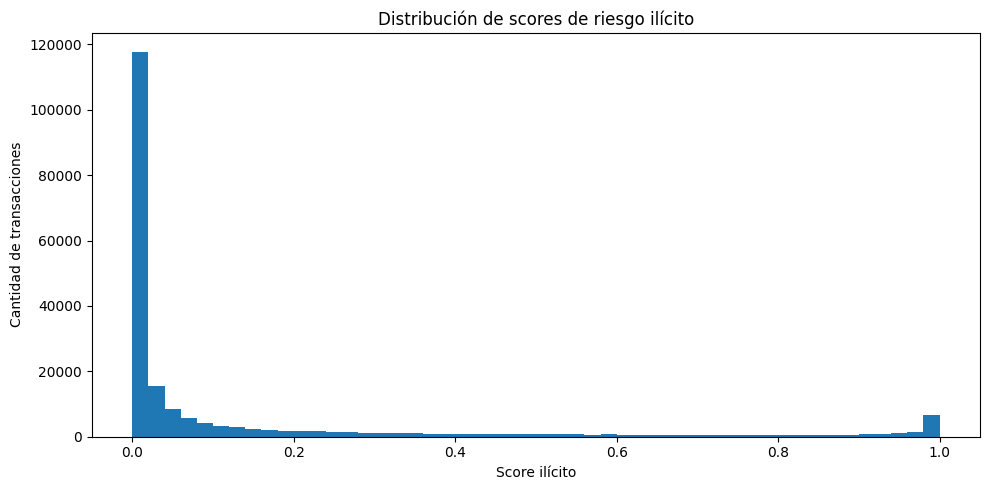

Guardado: /home/lucho/aml-gnn-tesis/reports/figures/platform_score_distribution.png


In [23]:
# Distribución de scores
plt.figure(figsize=(10, 5))
plt.hist(platform_predictions_df["score_illicit"], bins=50)
plt.title("Distribución de scores de riesgo ilícito")
plt.xlabel("Score ilícito")
plt.ylabel("Cantidad de transacciones")
plt.tight_layout()

score_distribution_path = figures_dir / "platform_score_distribution.png"
plt.savefig(score_distribution_path, dpi=300)
plt.show()

print("Guardado:", score_distribution_path)

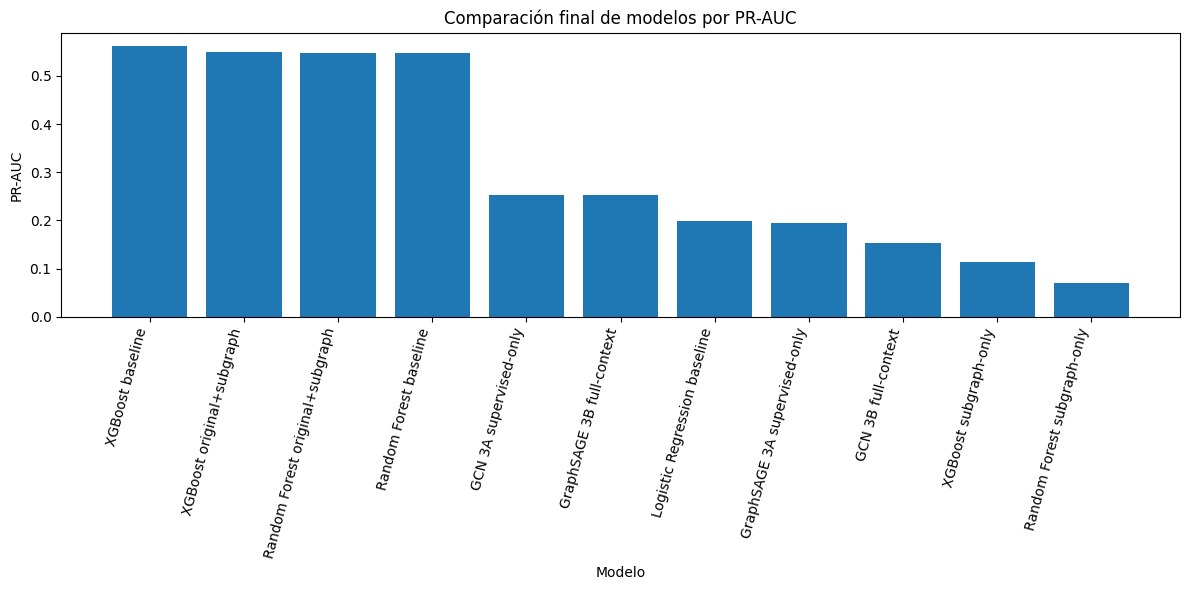

Guardado: /home/lucho/aml-gnn-tesis/reports/figures/platform_final_model_pr_auc_comparison.png


In [24]:
# Top modelos por PR-AUC
plot_model_df = final_model_comparison_df.sort_values(
    by="pr_auc",
    ascending=False
)

plt.figure(figsize=(12, 6))
plt.bar(plot_model_df["model"], plot_model_df["pr_auc"])
plt.title("Comparación final de modelos por PR-AUC")
plt.xlabel("Modelo")
plt.ylabel("PR-AUC")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()

final_model_fig_path = figures_dir / "platform_final_model_pr_auc_comparison.png"
plt.savefig(final_model_fig_path, dpi=300)
plt.show()

print("Guardado:", final_model_fig_path)

## Validación final de archivos generados

In [25]:
# Verificando archivos exportados
expected_outputs = {
    "platform_predictions": platform_predictions_path,
    "platform_alerts_top": platform_alerts_top_path,
    "subgraph_alerts": subgraph_alerts_path,
    "final_model_comparison": final_model_comparison_path,
    "platform_metrics_summary": platform_metrics_summary_path,
    "platform_export_metadata": platform_export_metadata_path,
    "score_distribution_figure": score_distribution_path,
    "final_model_pr_auc_figure": final_model_fig_path,
}

for name, path in expected_outputs.items():
    if path is None:
        print(name, "-> No generado")
    else:
        print(name, "->", Path(path).exists(), "|", path)

platform_predictions -> True | /home/lucho/aml-gnn-tesis/data/processed/elliptic/platform_predictions.parquet
platform_alerts_top -> True | /home/lucho/aml-gnn-tesis/data/processed/elliptic/platform_alerts_top.parquet
subgraph_alerts -> True | /home/lucho/aml-gnn-tesis/data/processed/elliptic/subgraph_alerts.parquet
final_model_comparison -> True | /home/lucho/aml-gnn-tesis/reports/tables/final_model_comparison.csv
platform_metrics_summary -> True | /home/lucho/aml-gnn-tesis/reports/metrics/platform_metrics_summary.json
platform_export_metadata -> True | /home/lucho/aml-gnn-tesis/reports/metrics/platform_export_metadata.json
score_distribution_figure -> True | /home/lucho/aml-gnn-tesis/reports/figures/platform_score_distribution.png
final_model_pr_auc_figure -> True | /home/lucho/aml-gnn-tesis/reports/figures/platform_final_model_pr_auc_comparison.png
